# Predicting Next-Day Closing Price of Cryptocurrencies using Random Forest Regression
This Python script implements a standard Random Forest Regressor model to predict the next day's closing price for cryptocurrencies. It loads historical market data, performs feature engineering (e.g., moving averages, daily returns) for each cryptocurrency group, and then trains a single, unified Random Forest Regressor model on the combined, scaled dataset. The model's performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R2), and the trained model and its scaler are saved for future use.

Feature Engineering Features include:

Market indicators: open, high, low, volume, market, spread, close_ratio

Technical indicators: prev_close, daily_return, ma_3, ma_7, volume_change

Overall Random Forest Regressor Model Evaluation:
Mean Absolute Error (MAE): 1.55
Root Mean Squared Error (RMSE): 34.95
R-squared (R2): 0.797


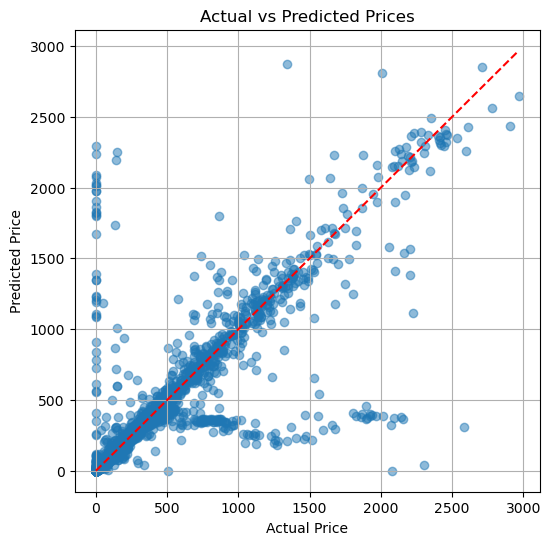


Model Summary: {'Model': 'Random Forest', 'MAE': 1.553872568248448, 'RMSE': 34.95162204574502, 'R²': 0.7972844132714034}

Model and scaler saved as 'crypto_unified_random_forest.pkl' and 'crypto_unified_scaler_random_forest.pkl'.

Sample Predictions from Loaded Model:
[0.28345909 0.270362   0.27575839 0.22421454 0.19561594]

Top 5 coins by average volume: ['USDT', 'TRX', 'XRP', 'ZEC', 'TRUE']


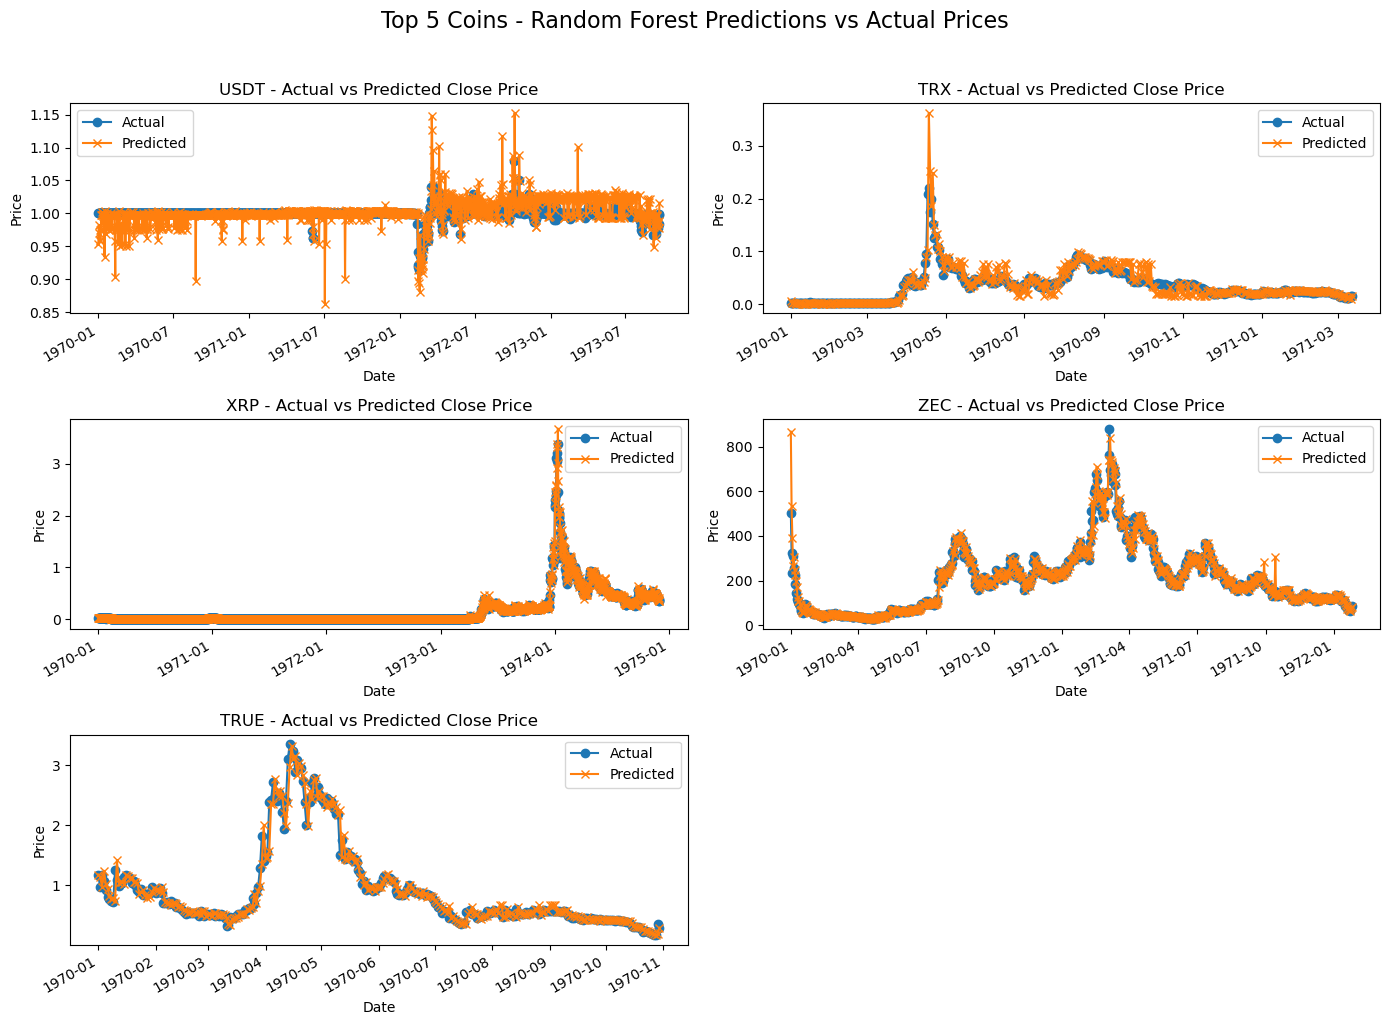


Mean Absolute Error (MAE) per Top Coin:
USDT: MAE = 0.0113
TRX: MAE = 0.0072
XRP: MAE = 0.0136
ZEC: MAE = 13.6982
TRUE: MAE = 0.0725


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib

# Load the dataset from GitHub
url = 'https://raw.githubusercontent.com/deysoumyadey/UofT-DSI-Cohort5-ML-T1/main/crypto-markets.csv'
df = pd.read_csv(url)


# Sort the DataFrame first by 'symbol' and then by 'date'.
df = df.sort_values(by=['symbol', 'date']).copy()

# Create target: next day's close.
df['target'] = df.groupby('symbol')['close'].shift(-1)

# Feature Engineering
# 'prev_close': Previous day's closing price.
df['prev_close'] = df.groupby('symbol')['close'].shift(1)
# 'daily_return': Daily return based on open and close prices.
df['daily_return'] = (df['close'] - df['open']) / df['open']
# 'ma_3': 3-day moving average of the closing price.
# .reset_index(level=0, drop=True) is used to align the index after groupby().rolling().
df['ma_3'] = df.groupby('symbol')['close'].rolling(3).mean().reset_index(level=0, drop=True)
# 'ma_7': 7-day moving average of the closing price.
df['ma_7'] = df.groupby('symbol')['close'].rolling(7).mean().reset_index(level=0, drop=True)
# 'volume_change': Percentage change in trading volume from the previous day.
df['volume_change'] = df.groupby('symbol')['volume'].pct_change()

# Drop rows with NaN values that resulted from feature engineering 
# replace any remaining infinite values (from division by zero in daily_return, etc.)
# with NaN and then drop those rows.
df = df.dropna()
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# These are the independent variables that will be used to predict the 'target'.
features = ['open', 'high', 'low', 'volume', 'market', 'spread', 'close_ratio',
            'prev_close', 'daily_return', 'ma_3', 'ma_7', 'volume_change']

# Separate features (X) and target (y) for the entire processed dataset.
X = df[features]
y = df['target']


# Split the data into training and testing sets.
# test_size=0.2 means 20% of the data will be used for testing.
# shuffle=False to preserve the chronological order,
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initialize and fit the StandardScaler.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Random Forest Regressor model.
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) 
model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set.
predictions = model.predict(X_test_scaled)

# Evaluate the model's performance using standard regression metrics.
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

# Print the evaluation metrics for the unified model.
print("Overall Random Forest Regressor Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.3f}")


plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.show()

def get_model_summary(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

summary = get_model_summary("Random Forest", y_test, predictions)
print("\nModel Summary:", summary)


# Save the trained model and the fitted scaler.
joblib.dump(model, 'crypto_unified_random_forest.pkl')
joblib.dump(scaler, 'crypto_unified_scaler_random_forest.pkl') 

print("\nModel and scaler saved as 'crypto_unified_random_forest.pkl' and 'crypto_unified_scaler_random_forest.pkl'.")

# Load the saved model and scaler 
loaded_model = joblib.load('crypto_unified_random_forest.pkl')
loaded_scaler = joblib.load('crypto_unified_scaler_random_forest.pkl')

# Use a few test samples to check predictions from the loaded model
sample_data = X_test.iloc[:5]
scaled_sample = loaded_scaler.transform(sample_data)
sample_predictions = loaded_model.predict(scaled_sample)

print("\nSample Predictions from Loaded Model:")
print(sample_predictions)


# Add 'symbol' and 'date' back to test set
X_test_with_meta = df.loc[X_test.index, ['symbol', 'date']].copy()
X_test_with_meta['actual'] = y_test.values
X_test_with_meta['predicted'] = predictions

# Identify top 5 coins by average volume that are present in the test set
available_symbols = X_test_with_meta['symbol'].unique()
top_5_symbols = (
    df[df['symbol'].isin(available_symbols)]
    .groupby('symbol')['volume']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)


print("\nTop 5 coins by average volume:", top_5_symbols)

# Plot actual vs predicted for top 5 coins
plt.figure(figsize=(14, 10))
for i, symbol in enumerate(top_5_symbols, 1):
    coin_data = X_test_with_meta[X_test_with_meta['symbol'] == symbol]
    coin_data_sorted = coin_data.sort_values('date')

    plt.subplot(3, 2, i)
    plt.plot(coin_data_sorted['date'], coin_data_sorted['actual'], label='Actual', marker='o')
    plt.plot(coin_data_sorted['date'], coin_data_sorted['predicted'], label='Predicted', marker='x')
    plt.title(f"{symbol} - Actual vs Predicted Close Price")
    plt.xlabel("Date")
    plt.ylabel("Price")

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=30, ha='right')

    plt.legend()
    plt.tight_layout()

    # Save individual plot as PNG
    plt.savefig(f'{symbol}_actual_vs_predicted.png')

plt.suptitle("Top 5 Coins - Random Forest Predictions vs Actual Prices", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Print MAE for each top coin
print("\nMean Absolute Error (MAE) per Top Coin:")
for symbol in top_5_symbols:
    coin_data = X_test_with_meta[X_test_with_meta['symbol'] == symbol]
    if not coin_data.empty: 
        mae_coin = mean_absolute_error(coin_data['actual'], coin_data['predicted'])
        print(f"{symbol}: MAE = {mae_coin:.4f}")
    else:
        print(f"{symbol}: No data in test set, skipped.")

